### Шаг 1. Настройка окружения и параметров
Импортируем библиотеки и задаем глобальные переменные. Целевой размер TARGET_SIZE установлен в 1280, как вы и просили.

In [5]:
import cv2
import os
import numpy as np
from pathlib import Path
import shutil

# ================= НАСТРОЙКИ =================
IMAGES_DIR = "Hands/Hands"
MASKS_DIR = "segmentation_mask/SegmentationClass/"
OUTPUT_DIR = "yolo_dataset"
TARGET_SIZE = 1280  # Целевой размер для Letterbox (1280x1280)

MASK_EXT = ".png"  
INCLUDE_UNLABELED_AS_BACKGROUND = False

CLASSES = {"jewelry": 0}
THRESHOLD = 127
MIN_AREA = 15  # Отсекаем шум меньше 15 пикселей

### Шаг 2. Логика Letterbox и пересчет координат
YOLO требует квадратные изображения. Мы используем Letterbox: картинка масштабируется с сохранением пропорций и помещается в центр серого фона (цвет 114 — стандарт YOLO). 
Важно: При таком ресайзе мы автоматически пересчитываем координаты боксов, чтобы они идеально совпадали с новым изображением.

In [6]:
def get_letterbox_params(orig_w, orig_h, target_size=1280):
    """Вычисляет параметры масштабирования и padding для Letterbox."""
    scale = min(target_size / orig_w, target_size / orig_h)
    new_w, new_h = int(orig_w * scale), int(orig_h * scale)
    dw = (target_size - new_w) // 2  # Padding по ширине
    dh = (target_size - new_h) // 2  # Padding по высоте
    return scale, dw, dh

def apply_letterbox_to_image(img, target_size=1280):
    """Применяет Letterbox к изображению (создает квадрат 1280x1280)."""
    h, w = img.shape[:2]
    scale, dw, dh = get_letterbox_params(w, h, target_size)
    
    # Уменьшаем/увеличиваем изображение с сохранением пропорций
    resized = cv2.resize(img, (int(w * scale), int(h * scale)), interpolation=cv2.INTER_LINEAR)
    
    # Создаем серый фон (114 - стандартный цвет YOLO)
    canvas = np.full((target_size, target_size, 3), 114, dtype=np.uint8)
    # Вставляем картинку в центр
    canvas[dh:dh+resized.shape[0], dw:dw+resized.shape[1]] = resized
    
    return canvas

def apply_letterbox_to_bboxes(bboxes, orig_w, orig_h, target_size=1280):
    """
    Пересчитывает нормализованные YOLO-координаты с учетом Letterbox.
    bboxes: список списков [cls, xc, yc, w, h] (нормализованные к orig_w, orig_h)
    """
    scale, dw, dh = get_letterbox_params(orig_w, orig_h, target_size)
    new_bboxes = []
    
    for bbox in bboxes:
        cls, xc, yc, w, h = bbox
        
        # 1. Переводим в абсолютные пиксели на оригинале
        abs_xc, abs_yc = xc * orig_w, yc * orig_h
        abs_w, abs_h = w * orig_w, h * orig_h
        
        # 2. Применяем скейл и сдвиг (padding)
        lb_xc = abs_xc * scale + dw
        lb_yc = abs_yc * scale + dh
        lb_w = abs_w * scale
        lb_h = abs_h * scale
        
        # 3. Нормализуем относительно нового target_size (1280)
        new_xc = lb_xc / target_size
        new_yc = lb_yc / target_size
        new_w = lb_w / target_size
        new_h = lb_h / target_size
        
        # 4. Математическая защита: обрезаем углы, чтобы избежать y_min < 0 в albumentations
        x_min = max(0.0, new_xc - new_w / 2)
        y_min = max(0.0, new_yc - new_h / 2)
        x_max = min(1.0, new_xc + new_w / 2)
        y_max = min(1.0, new_yc + new_h / 2)
        
        final_w = x_max - x_min
        final_h = y_max - y_min
        
        if final_w < 0.005 or final_h < 0.005:
            continue  # Отсеиваем микроскопические артефакты
            
        final_xc = x_min + final_w / 2
        final_yc = y_min + final_h / 2
        
        new_bboxes.append([cls, final_xc, final_yc, final_w, final_h])
        
    return new_bboxes

### Шаг 3. Конвертация масок в YOLO и создание исходного датасета
На этом этапе мы находим контуры на масках, применяем Letterbox к картинкам (делаем их 1280x1280), пересчитываем координаты боксов под новый размер и разбиваем данные на train/val/test.

In [7]:
def mask_to_raw_yolo_bboxes(mask_path):
    """Находит контуры на маске и возвращает сырые нормализованные координаты."""
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None: return []
    
    _, binary = cv2.threshold(mask, THRESHOLD, 255, cv2.THRESH_BINARY)
    if np.sum(binary) == 0: return []
        
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = []
    mh, mw = mask.shape[:2]
    
    for cnt in contours:
        if cv2.contourArea(cnt) < MIN_AREA: continue
        x, y, w, h = cv2.boundingRect(cnt)
        
        xc = (x + (w // 2)) / mw
        yc = (y + (h // 2)) / mh
        wn = w / mw
        hn = h / mh
        
        if wn <= 0.0 or hn <= 0.0: continue
        boxes.append([CLASSES['jewelry'], xc, yc, wn, hn])
        
    return boxes

def process_dataset():
    print("🚀 Начинаем создание датасета с Letterbox...")
    if os.path.exists(OUTPUT_DIR):
        shutil.rmtree(OUTPUT_DIR)
        
    for s in ['train', 'val', 'test']:
        os.makedirs(os.path.join(OUTPUT_DIR, 'images', s), exist_ok=True)
        os.makedirs(os.path.join(OUTPUT_DIR, 'labels', s), exist_ok=True)

    img_files = [f for f in os.listdir(IMAGES_DIR) if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}]
    np.random.seed(42)
    np.random.shuffle(img_files)
    
    n = len(img_files)
    train_end, val_end = int(0.8 * n), int(0.9 * n)
    
    labeled_count, skipped_count = 0, 0

    for i, img_name in enumerate(img_files):
        split = 'train' if i < train_end else ('val' if i < val_end else 'test')
        
        img_path = os.path.join(IMAGES_DIR, img_name)
        mask_path = os.path.join(MASKS_DIR, Path(img_name).stem + MASK_EXT)
        
        img = cv2.imread(img_path)
        if img is None: continue
        h, w = img.shape[:2]
        
        has_mask = os.path.exists(mask_path)
        if not has_mask and not INCLUDE_UNLABELED_AS_BACKGROUND:
            skipped_count += 1
            continue
            
        # 1. Применяем Letterbox к изображению (оно становится 1280x1280)
        lb_img = apply_letterbox_to_image(img, TARGET_SIZE)
        
        # 2. Получаем сырые боксы и пересчитываем их под Letterbox
        raw_bboxes = mask_to_raw_yolo_bboxes(mask_path) if has_mask else []
        final_bboxes = apply_letterbox_to_bboxes(raw_bboxes, w, h, TARGET_SIZE)
        
        # 3. Сохраняем картинку и лейблы
        cv2.imwrite(os.path.join(OUTPUT_DIR, 'images', split, img_name), lb_img)
        
        label_path = os.path.join(OUTPUT_DIR, 'labels', split, Path(img_name).stem + ".txt")
        with open(label_path, 'w') as f:
            for box in final_bboxes:
                f.write(f"{int(box[0])} {box[1]:.6f} {box[2]:.6f} {box[3]:.6f} {box[4]:.6f}\n")
                
        if final_bboxes: labeled_count += 1

    print(f"✅ Готово! Размечено: {labeled_count} | Пропущено: {skipped_count}")

if __name__ == "__main__":
    process_dataset()

🚀 Начинаем создание датасета с Letterbox...
✅ Готово! Размечено: 3178 | Пропущено: 7897


### Шаг 4. Визуальная проверка
Рисуем боксы на 5 случайных картинках из train, чтобы убедиться, что Letterbox сработал корректно, пропорции сохранены, а боксы не уехали на черные поля.

In [8]:
img_dir = os.path.join(OUTPUT_DIR, "images/train")
label_dir = os.path.join(OUTPUT_DIR, "labels/train")
out_dir = os.path.join(OUTPUT_DIR, "visual_check")
os.makedirs(out_dir, exist_ok=True)

files = os.listdir(img_dir)[:5]

for f in files:
    img_path = os.path.join(img_dir, f)
    label_path = os.path.join(label_dir, Path(f).stem + ".txt")
    
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as file:
            for line in file:
                parts = line.strip().split()
                if len(parts) == 5:
                    cls, xc, yc, bw, bh = map(float, parts)
                    
                    x_min = int((xc - bw / 2) * w)
                    y_min = int((yc - bh / 2) * h)
                    x_max = int((xc + bw / 2) * w)
                    y_max = int((yc + bh / 2) * h)
                    
                    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
                    cv2.putText(img, f"jewelry", (x_min, y_min - 5), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    
    cv2.imwrite(os.path.join(out_dir, f"check_{f}"), img)
print("✅ Проверочные изображения сохранены в yolo_dataset/visual_check")

✅ Проверочные изображения сохранены в yolo_dataset/visual_check


### Шаг 5. Санитарная очистка датасета
На случай микро-ошибок округления float. Обрезает координаты в жесткий диапазон и удаляет битые боксы. Запускайте, если планируете использовать Albumentations.

In [9]:
def sanitize_dataset():
    print("🔍 Начинаю проверку и очистку всех .txt файлов...")
    fixed_files_count = 0
    removed_boxes_count = 0

    for split in ['train', 'val', 'test']:
        label_dir = os.path.join(OUTPUT_DIR, 'labels', split)
        if not os.path.exists(label_dir): continue
            
        for filename in os.listdir(label_dir):
            if not filename.endswith('.txt'): continue
            filepath = os.path.join(label_dir, filename)
            
            with open(filepath, 'r') as f: lines = f.readlines()
                
            clean_lines = []
            file_was_modified = False
            
            for line in lines:
                parts = line.strip().split()
                if len(parts) != 5: continue
                    
                try:
                    cls, xc, yc, w, h = int(parts[0]), float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                except ValueError: continue

                xc = max(0.0001, min(0.9999, xc))
                yc = max(0.0001, min(0.9999, yc))
                w = max(0.0001, min(0.9999, w))
                h = max(0.0001, min(0.9999, h))
                
                if w < 0.005 or h < 0.005:
                    removed_boxes_count += 1
                    file_was_modified = True
                    continue
                
                clean_lines.append(f"{cls} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")
                file_was_modified = True

            if file_was_modified:
                with open(filepath, 'w') as f: f.writelines(clean_lines)
                fixed_files_count += 1

    print(f"✅ Очистка завершена! Исправлено файлов: {fixed_files_count}, удалено мусорных боксов: {removed_boxes_count}")

if __name__ == "__main__":
    sanitize_dataset()

🔍 Начинаю проверку и очистку всех .txt файлов...
✅ Очистка завершена! Исправлено файлов: 3178, удалено мусорных боксов: 0


### Шаг 6. Аугментация датасета
Создаем отдельную папку yolo_dataset_augmented. Копируем val/test без изменений, а train расширяем с помощью Albumentations (флип, цвета). 
Так как картинки уже 1280x1280, аугментации работают быстро, а математическая защита внутри parse_and_fix_yolo_label гарантирует, что albumentations не упадет с ошибкой ValueError.

In [10]:
import albumentations as A

SOURCE_DATASET_DIR = "yolo_dataset"
TARGET_DATASET_DIR = "yolo_dataset_augmented"
NUM_AUGS_PER_IMAGE = 1 

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.8),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.8),
], bbox_params=A.BboxParams(
    format='yolo', label_fields=['class_labels'], min_area=10, check_each_transform=True
))

def parse_and_fix_yolo_label(label_path):
    bboxes, class_labels = [], []
    if not os.path.exists(label_path): return bboxes, class_labels
        
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls = int(parts[0])
                xc, yc, w, h = map(float, parts[1:5])
                
                x_min = max(0.0, xc - (w / 2))
                y_min = max(0.0, yc - (h / 2))
                x_max = min(1.0, xc + (w / 2))
                y_max = min(1.0, yc + (h / 2))
                
                new_w = x_max - x_min
                new_h = y_max - y_min
                
                if new_w < 0.01 or new_h < 0.01: continue 
                    
                bboxes.append([x_min + (new_w / 2), y_min + (new_h / 2), new_w, new_h])
                class_labels.append(cls)
    return bboxes, class_labels

def save_yolo_label(label_path, bboxes, class_labels):
    with open(label_path, 'w') as f:
        for bbox, cls in zip(bboxes, class_labels):
            f.write(f"{cls} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")

def create_new_dataset():
    print("🚀 Начинаем создание аугментированного датасета...")
    
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(TARGET_DATASET_DIR, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(TARGET_DATASET_DIR, 'labels', split), exist_ok=True)

    for split in ['val', 'test']:
        for folder, ext in [('images', ['.jpg', '.jpeg', '.png']), ('labels', ['.txt'])]:
            src_dir = os.path.join(SOURCE_DATASET_DIR, folder, split)
            tgt_dir = os.path.join(TARGET_DATASET_DIR, folder, split)
            if os.path.exists(src_dir):
                for f in os.listdir(src_dir):
                    if Path(f).suffix.lower() in ext:
                        shutil.copy(os.path.join(src_dir, f), os.path.join(tgt_dir, f))

    src_train_img_dir = os.path.join(SOURCE_DATASET_DIR, 'images', 'train')
    src_train_lbl_dir = os.path.join(SOURCE_DATASET_DIR, 'labels', 'train')
    tgt_train_img_dir = os.path.join(TARGET_DATASET_DIR, 'images', 'train')
    tgt_train_lbl_dir = os.path.join(TARGET_DATASET_DIR, 'labels', 'train')
    
    img_files = [f for f in os.listdir(src_train_img_dir) if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}]
    augmented_count = 0
    
    for img_name in img_files:
        img_path = os.path.join(src_train_img_dir, img_name)
        label_path = os.path.join(src_train_lbl_dir, Path(img_name).stem + ".txt")
        
        img = cv2.imread(img_path)
        if img is None: continue
            
        bboxes, class_labels = parse_and_fix_yolo_label(label_path)
        
        shutil.copy(img_path, os.path.join(tgt_train_img_dir, img_name))
        shutil.copy(label_path, os.path.join(tgt_train_lbl_dir, Path(img_name).stem + ".txt"))
        
        if len(bboxes) == 0: continue

        for aug_idx in range(NUM_AUGS_PER_IMAGE):
            try:
                transformed = transform(image=img, bboxes=bboxes, class_labels=class_labels)
            except ValueError as e:
                print(f"❌ Ошибка на файле {img_name}: {e}")
                continue # Пропускаем проблемный файл, чтобы не прерывать весь датасет
            
            aug_img = transformed['image']
            aug_bboxes = transformed['bboxes']
            aug_labels = transformed['class_labels']
            
            if len(aug_bboxes) == 0: continue
                
            aug_img_name = f"{Path(img_name).stem}_aug{aug_idx}{Path(img_name).suffix}"
            aug_label_name = f"{Path(img_name).stem}_aug{aug_idx}.txt"
            
            cv2.imwrite(os.path.join(tgt_train_img_dir, aug_img_name), aug_img)
            save_yolo_label(os.path.join(tgt_train_lbl_dir, aug_label_name), aug_bboxes, aug_labels)
            augmented_count += 1

    print(f"✅ Готово! Создано {augmented_count} аугментированных изображений.")
    
    yaml_content = f"""path: {os.path.abspath(TARGET_DATASET_DIR)}
train: images/train
val: images/val
test: images/test
nc: 1
names:
  0: jewelry
"""
    with open(os.path.join(TARGET_DATASET_DIR, "data.yaml"), 'w') as f:
        f.write(yaml_content)
    print("📄 Создан data.yaml")

if __name__ == "__main__":
    create_new_dataset()

🚀 Начинаем создание аугментированного датасета...
✅ Готово! Создано 2550 аугментированных изображений.
📄 Создан data.yaml


### Шаг 7. Статистика датасета
Перед визуальной оценкой полезно посмотреть сухие цифры: сколько изображений в каждом сплите, сколько всего боксов, есть ли пустые файлы (фон).

In [11]:
import os
from pathlib import Path

def print_dataset_stats(dataset_dir):
    print(f"\n📊 Статистика датасета: {dataset_dir}")
    print("-" * 50)
    
    total_images = 0
    total_boxes = 0
    empty_labels = 0
    
    for split in ['train', 'val', 'test']:
        img_dir = os.path.join(dataset_dir, 'images', split)
        lbl_dir = os.path.join(dataset_dir, 'labels', split)
        
        if not os.path.exists(img_dir):
            print(f"{split}: папка не найдена")
            continue
            
        img_count = len([f for f in os.listdir(img_dir) if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}])
        
        boxes_in_split = 0
        empty_in_split = 0
        for lbl in os.listdir(lbl_dir):
            if not lbl.endswith('.txt'): continue
            with open(os.path.join(lbl_dir, lbl), 'r') as f:
                lines = [l for l in f.readlines() if l.strip()]
            boxes_in_split += len(lines)
            if len(lines) == 0:
                empty_in_split += 1
        
        total_images += img_count
        total_boxes += boxes_in_split
        empty_labels += empty_in_split
        
        print(f"{split:>5}: {img_count:>5} изображений | {boxes_in_split:>6} боксов | {empty_in_split:>4} пустых лейблов")
    
    print("-" * 50)
    print(f"ИТОГО: {total_images} изображений, {total_boxes} боксов")
    if empty_labels > 0:
        print(f"⚠️  {empty_labels} изображений без объектов (фон)")

# Проверяем оба датасета
print_dataset_stats("yolo_dataset")
print_dataset_stats("yolo_dataset_augmented")


📊 Статистика датасета: yolo_dataset
--------------------------------------------------
train:  2572 изображений |   3137 боксов |    1 пустых лейблов
  val:   294 изображений |    362 боксов |    0 пустых лейблов
 test:   313 изображений |    380 боксов |    0 пустых лейблов
--------------------------------------------------
ИТОГО: 3179 изображений, 3879 боксов
⚠️  1 изображений без объектов (фон)

📊 Статистика датасета: yolo_dataset_augmented
--------------------------------------------------
train:  5122 изображений |   6217 боксов |    1 пустых лейблов
  val:   294 изображений |    362 боксов |    0 пустых лейблов
 test:   313 изображений |    380 боксов |    0 пустых лейблов
--------------------------------------------------
ИТОГО: 5729 изображений, 6959 боксов
⚠️  1 изображений без объектов (фон)


### Шаг 8. Визуальная оценка датасета
Измените переменную DATASET_TO_SHOW и SPLIT, чтобы посмотреть случайные изображения из нужного датасета и сплита. На картинках зелёным нарисованы bounding box.

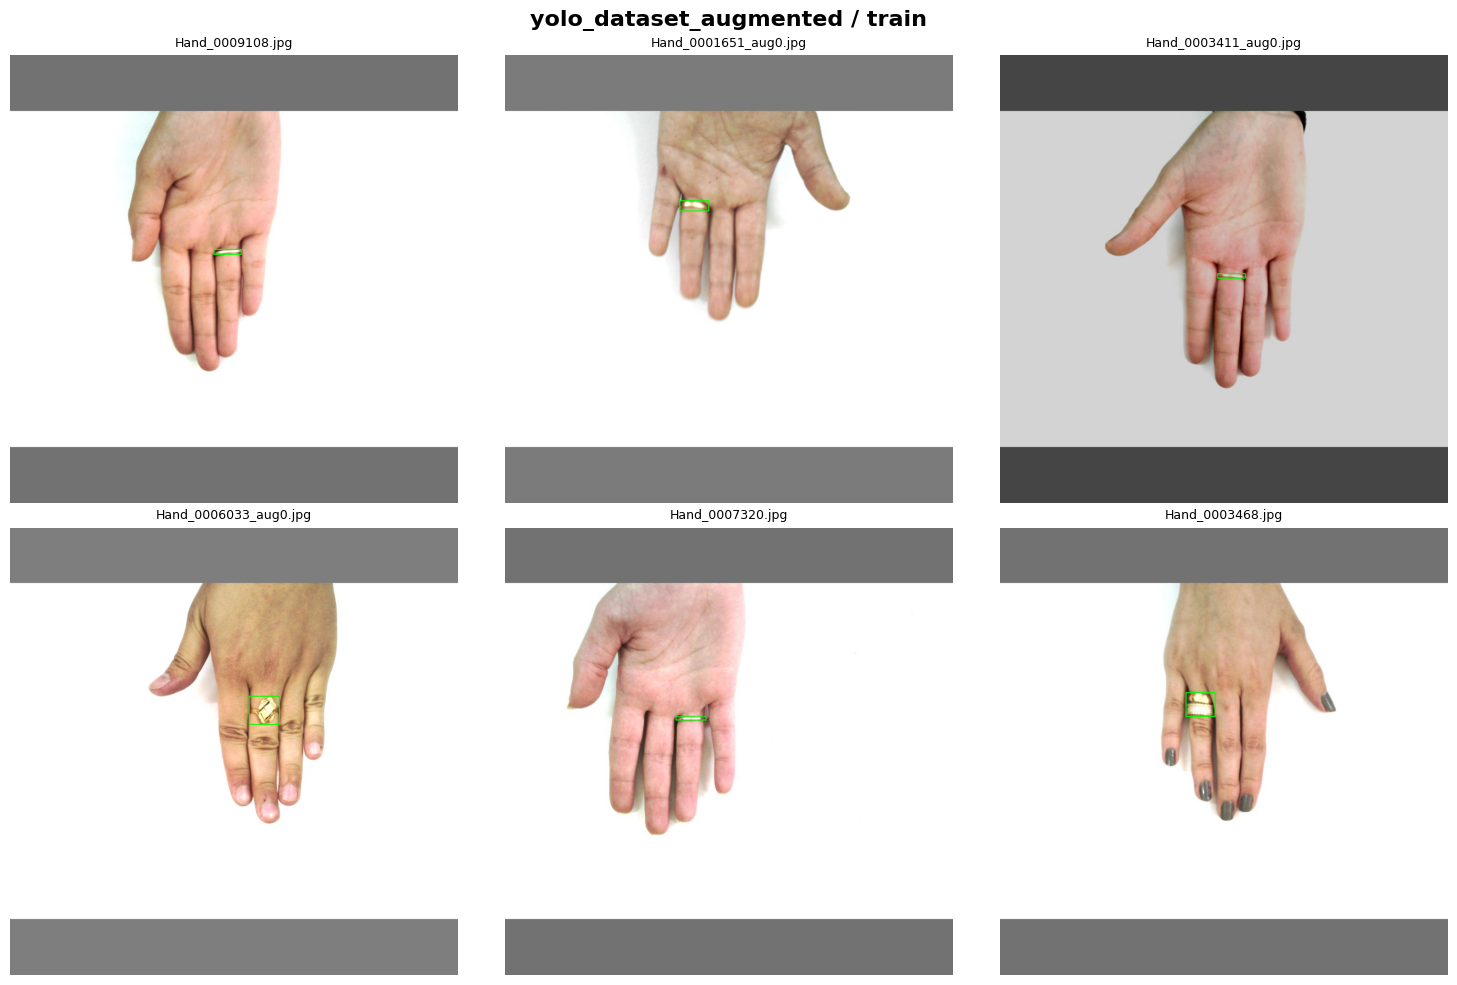

In [13]:
import cv2
import os
import random
import matplotlib.pyplot as plt
from pathlib import Path

# ================= НАСТРОЙКИ ОТОБРАЖЕНИЯ =================
DATASET_TO_SHOW = "yolo_dataset_augmented"  # или "yolo_dataset"
SPLIT = "train"                             # train / val / test
NUM_IMAGES = 6                              # сколько картинок показать
# =========================================================

def visualize_dataset(dataset_dir, split, num_images=6):
    img_dir = os.path.join(dataset_dir, 'images', split)
    lbl_dir = os.path.join(dataset_dir, 'labels', split)
    
    if not os.path.exists(img_dir):
        print(f"❌ Папка не найдена: {img_dir}")
        return
    
    all_images = [f for f in os.listdir(img_dir) if Path(f).suffix.lower() in {'.jpg', '.jpeg', '.png'}]
    selected = random.sample(all_images, min(num_images, len(all_images)))
    
    cols = 3
    rows = (len(selected) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() if rows > 1 else [axes] if len(selected) == 1 else axes
    
    for i, fname in enumerate(selected):
        img = cv2.imread(os.path.join(img_dir, fname))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        lbl_path = os.path.join(lbl_dir, Path(fname).stem + ".txt")
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5: continue
                    cls, xc, yc, bw, bh = map(float, parts)
                    
                    x_min = int((xc - bw / 2) * w)
                    y_min = int((yc - bh / 2) * h)
                    x_max = int((xc + bw / 2) * w)
                    y_max = int((yc + bh / 2) * h)
                    
                    cv2.rectangle(img_rgb, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
        
        axes[i].imshow(img_rgb)
        axes[i].set_title(fname, fontsize=9)
        axes[i].axis('off')
    
    # Скрываем пустые подграфики
    for j in range(len(selected), len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f"{dataset_dir} / {split}", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_dataset(DATASET_TO_SHOW, SPLIT, NUM_IMAGES)

### Шаг 9. Сравнение оригинала и аугментированной версии
Находим случайное изображение, у которого есть аугментированная копия (суффикс _aug0), и показываем их рядом. Это наглядно демонстрирует, что флип и цвета применились корректно, а боксы остались на объектах.

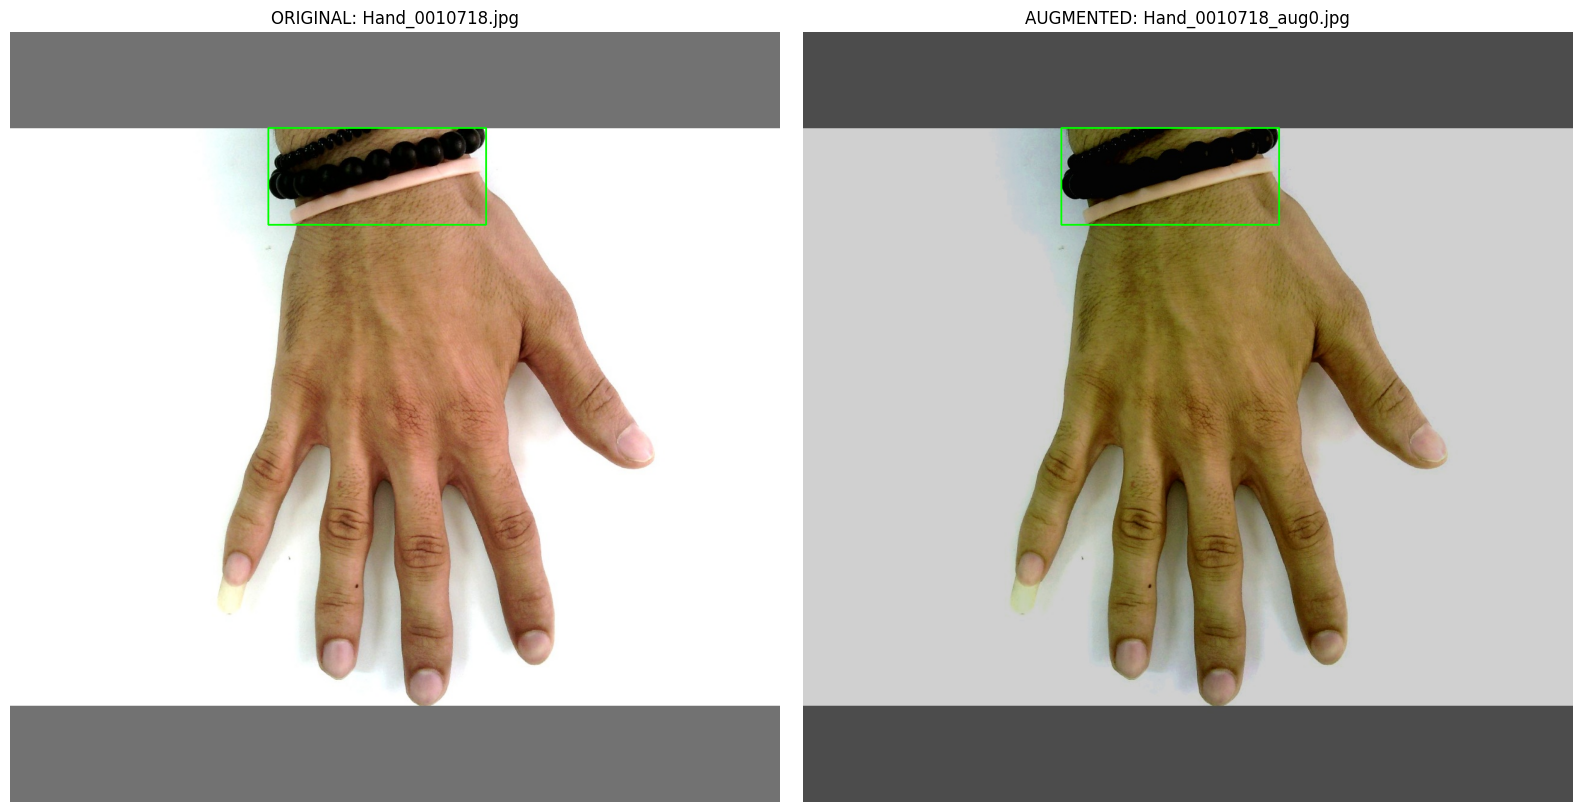

In [33]:
import cv2
import os
import random
import matplotlib.pyplot as plt
from pathlib import Path

def compare_original_and_aug():
    src_img_dir = os.path.join("yolo_dataset", "images/train")
    src_lbl_dir = os.path.join("yolo_dataset", "labels/train")
    aug_img_dir = os.path.join("yolo_dataset_augmented", "images/train")
    aug_lbl_dir = os.path.join("yolo_dataset_augmented", "labels/train")
    
    # Ищем файлы, у которых есть аугментированная копия
    aug_files = [f for f in os.listdir(aug_img_dir) if "_aug0" in f]
    if not aug_files:
        print("❌ Аугментированных копий не найдено. Сначала запустите аугментацию.")
        return
    
    aug_fname = random.choice(aug_files)
    orig_fname = aug_fname.replace("_aug0", "")
    
    def draw_bboxes(img_path, lbl_path):
        img = cv2.imread(img_path)
        if img is None: return None
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5: continue
                    cls, xc, yc, bw, bh = map(float, parts)
                    x_min = int((xc - bw / 2) * w)
                    y_min = int((yc - bh / 2) * h)
                    x_max = int((xc + bw / 2) * w)
                    y_max = int((yc + bh / 2) * h)
                    cv2.rectangle(img_rgb, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
        return img_rgb
    
    orig_img = draw_bboxes(
        os.path.join(src_img_dir, orig_fname),
        os.path.join(src_lbl_dir, Path(orig_fname).stem + ".txt")
    )
    aug_img = draw_bboxes(
        os.path.join(aug_img_dir, aug_fname),
        os.path.join(aug_lbl_dir, Path(aug_fname).stem + ".txt")
    )
    
    if orig_img is None or aug_img is None:
        print("❌ Не удалось загрузить изображения.")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(orig_img)
    axes[0].set_title(f"ORIGINAL: {orig_fname}", fontsize=12)
    axes[0].axis('off')
    axes[1].imshow(aug_img)
    axes[1].set_title(f"AUGMENTED: {aug_fname}", fontsize=12)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

compare_original_and_aug()